# CIFAR 10 Classification

## 1.1 Training and testing a Deep neural network model in pytorch similar to pytorch documentation

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [ ]:
# Define transformations for the training and testing data
# The images are converted to tensors and normalized to have a mean of 0.5 and a standard deviation of 0.5 for each color channel.
# to make the pixel values range from -1 to 1, and center at 0 this can help with convergence.
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]
)

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=False, transform=transform)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)


testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=False, transform=transform)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100.0%


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified


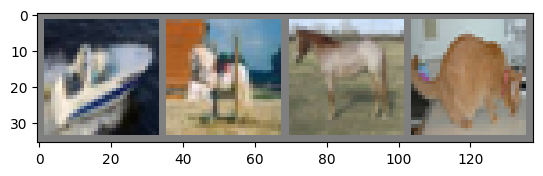

class: ship class: horse class: horse class: cat


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Function to show an image
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(npimg.transpose((1, 2, 0)))
    plt.show()

# Get some random training images
# the iter() function is used to create an iterator from the trainloader,
# and the next() function is called to retrieve the next batch of images and labels from the iterator.
# so for this instance we will just retrieve the first batch
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images
imshow(torchvision.utils.make_grid(images))

print(' '.join(f'class: {classes[labels[j]]}' for j in range(batch_size)))

In [15]:
import torch.nn as nn
import torch.nn.functional as F

class Net (nn.Module):
    def __init__(self):
        # the super() function is used to call the __init__ method of the parent class (nn.Module) to ensure that the base class is properly initialized.
        super(Net, self).__init__()
        # first convolutional layer takes 3 input channels (RGB) and produces 6 output(features) channels using a kernel size of 5
        # the output image size will be ((input_size - kernel_size + 2 * padding) / stride) + 1 which will be ((32 - 5 + 0) / 1) + 1 = 28
        self.conv1 = nn.Conv2d(3, 6, 5)
        # the max pooling layer is defined with a kernel size of 2 and a stride of 2, which will downsample the feature maps by a factor of 2.
        # in this case 28 will downsampled to 14
        self.pool= nn.MaxPool2d(2,2)
        # the second convolutional layer takes 6 input channels (from the previous layer) and produces 16 output channels using a kernel size of 5.
        # the output image size will be ((14 - 5 + 0) / 1) + 1 = 10
        self.conv2 = nn.Conv2d(6, 16, 5)
        # the fully connected layers are defined to take the output from the convolutional layers and produce the final class scores.
        # since in the forward method we will run the second convolutional layer through another max pooling layer the output image size will be downsampled to 5
        # so the input to the first fully connected layer will be 16 * 5 * 5 = 400 features which is 16 output channels * 5 height * 5 width
        # the 120 output features are arbitrary and can be adjusted based on the desired model complexity and performance.
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        # the second fully connected layer takes 120 input features which is the output from the first fully connected layer and produces 84 output features.
        # the 84 output features are also arbitrary and can be adjusted based on the desired model complexity and performance.
        self.fc2 = nn.Linear(120, 84)
        # the final fully connected layer takes 84 input features which is the output from the second fully connected layer and produces 10 output features
        # the 10 output features correspond to the 10 classes in the CIFAR-10 dataset, and will represent the predicted class scores for each input image.
        # we need the outputs to be logits (raw scores) because we will apply the CrossEntropyLoss which combines the softmax activation function
        # and the negative log-likelihood loss in one single class.
        self.fc3 = nn.Linear(84, 10)
        
    def forward(self, x):
        # the forward method defines how the input data flows through the network layers to produce the output.
        # the input x is passed through the first convolutional layer, followed by a ReLU activation function and a max pooling layer.
        x = self.pool(F.relu(self.conv1(x)))
        # same here
        x = self.pool(F.relu(self.conv2(x)))
        # the output of the final pooling layer is then flattened into a 1D vector to be fed into the fully connected layers.
        x = torch.flatten(x, 1)
        # the flattened output is passed througha relu activation function after each fully connected layer
        x = F.relu(self.fc1(x))
        # the output of the first fully connected layer is passed through the second fully connected layer, followed by a ReLU activation function.
        x = F.relu(self.fc2(x))
        # the final output is produced by passing the output of the second fully connected layer through the third fully connected layer,
        # which produces the class scores (logits) for each input image.
        x = self.fc3(x)
        return x
    
net = Net()

In [ ]:
import torch.optim as optim

# the CrossEntropyLoss is used as the loss function for training the network, which is suitable for multi-class classification problems like CIFAR-10.
criterion = nn.CrossEntropyLoss()
# the Stochastic Gradient Descent (SGD) optimizer is used to update the model's parameters during training, with a learning rate of 0.001 and a momentum of 0.9\
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)